**Task 2: Predict Future Stock Prices (Short-Term)**

Step 1: Install and Import Libraries

In [10]:
# Install yfinance (run once in Colab)
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import yfinance as yf
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

Step 2: Load Stock Data (Yahoo Finance)

We will use Apple stock (AAPL).

In [11]:
#Loading Data
ticker="AAPL"
data=yf.download(ticker, period="2y", interval="1d")
data.head()

/tmp/ipykernel_13179/4192738404.py:3: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data=yf.download(ticker, period="2y", interval="1d")
[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,
2024-04-25,168.357788,169.071296,166.633475,168.001034,50558300
2024-04-26,167.773117,169.794712,167.654189,168.347888,44838400
2024-04-29,171.935242,174.442423,171.538855,171.806409,68169400
2024-04-30,168.793839,173.411815,168.466813,171.766782,65934800
2024-05-01,167.773117,171.152367,167.584828,168.050591,50383100


Step 3: Data Exploration

In [13]:
#Understanding the data
data.shape
data.columns
data.info
data.describe

<bound method NDFrame.describe of Price            Close        High         Low        Open    Volume
Ticker            AAPL        AAPL        AAPL        AAPL      AAPL
Date                                                                
2024-04-25  168.357788  169.071296  166.633475  168.001034  50558300
2024-04-26  167.773117  169.794712  167.654189  168.347888  44838400
2024-04-29  171.935242  174.442423  171.538855  171.806409  68169400
2024-04-30  168.793839  173.411815  168.466813  171.766782  65934800
2024-05-01  167.773117  171.152367  167.584828  168.050591  50383100
...                ...         ...         ...         ...       ...
2026-04-20  273.049988  274.279999  270.290009  270.329987  36590200
2026-04-21  266.170013  272.799988  265.399994  271.500000  50209800
2026-04-22  273.170013  273.739990  266.869995  267.820007  43249200
2026-04-23  273.429993  275.769989  271.649994  275.049988  33399600
2026-04-24  271.059998  273.059998  269.649994  272.760010  38124500

[501 rows x 5 columns]>

Step 4: Feature Selection

In [14]:
#Defining the Features and Labels
features = ["Open", "High", "Low", "Volume"]
target='Close'
X=data[features]
y=data[target]

print(X)
print(y)

Price             Open        High         Low    Volume
Ticker            AAPL        AAPL        AAPL      AAPL
Date                                                    
2024-04-25  168.001034  169.071296  166.633475  50558300
2024-04-26  168.347888  169.794712  167.654189  44838400
2024-04-29  171.806409  174.442423  171.538855  68169400
2024-04-30  171.766782  173.411815  168.466813  65934800
2024-05-01  168.050591  171.152367  167.584828  50383100
...                ...         ...         ...       ...
2026-04-20  270.329987  274.279999  270.290009  36590200
2026-04-21  271.500000  272.799988  265.399994  50209800
2026-04-22  267.820007  273.739990  266.869995  43249200
2026-04-23  275.049988  275.769989  271.649994  33399600
2026-04-24  272.760010  273.059998  269.649994  38124500

[501 rows x 4 columns]
Ticker            AAPL
Date                  
2024-04-25  168.357788
2024-04-26  167.773117
2024-04-29  171.935242
2024-04-30  168.793839
2024-05-01  167.773117
...              

Step 5: Train-Test Split

In [15]:
#Splitting data into train and test
X_train, X_test, y_train, y_test= train_test_split(X,y, test_size=0.2, shuffle=False)
print(X_test)
print(y_test)

Price             Open        High         Low    Volume
Ticker            AAPL        AAPL        AAPL      AAPL
Date                                                    
2025-11-28  277.000815  278.739179  275.731983  20135600
2025-12-01  277.750120  283.155066  275.881873  46587700
2025-12-02  282.735435  287.131315  282.365785  53669500
2025-12-03  285.932471  288.350192  283.035157  43538700
2025-12-04  283.834407  284.463823  278.329548  43989100
...                ...         ...         ...       ...
2026-04-20  270.329987  274.279999  270.290009  36590200
2026-04-21  271.500000  272.799988  265.399994  50209800
2026-04-22  267.820007  273.739990  266.869995  43249200
2026-04-23  275.049988  275.769989  271.649994  33399600
2026-04-24  272.760010  273.059998  269.649994  38124500

[101 rows x 4 columns]
Ticker            AAPL
Date                  
2025-11-28  278.589325
2025-12-01  282.835358
2025-12-02  285.922455
2025-12-03  283.884369
2025-12-04  280.437592
...              

Step 6: Linear Regression Model

In [16]:
#Initializing the model
lr_model=LinearRegression()

#Traing the Model
lr_model.fit(X_train, y_train)

#Testing
y_predict=lr_model.predict(X_test)

#Evaluation
mse_error=mean_squared_error(y_test, y_predict)
r2_sr=r2_score(y_test,y_predict)
print(mse_error)
print(r2_sr)

2.1183638953026613
0.9781651281124619


Step 7: Random Forest Model

In [17]:
#Initializing RandomForestModel Regressor
rf_model=RandomForestRegressor(n_estimators=100,random_state=42)

#Training the RandomForest Regressor Model
rf_model.fit(X_train, y_train)

#Prediction
y_pred=rf_model.predict(X_test)

#Evaluation
mse_rf=mean_squared_error(y_test, y_pred)
r2_rf=r2_score(y_test, y_pred)

print(mse_rf)
print(r2_rf)

/usr/local/lib/python3.12/dist-packages/sklearn/base.py:1389: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


6.075198111266146
0.937380365693989


Random Forest Model Perfomance

**Explanation**

Random Forest uses multiple decision trees to model complex patterns and interactions between features.

**Observation**

In this case, Random Forest performed worse than Linear Regression.
Higher MSE and lower R² indicate less accurate predictions.

Step 8: Visualization Setup

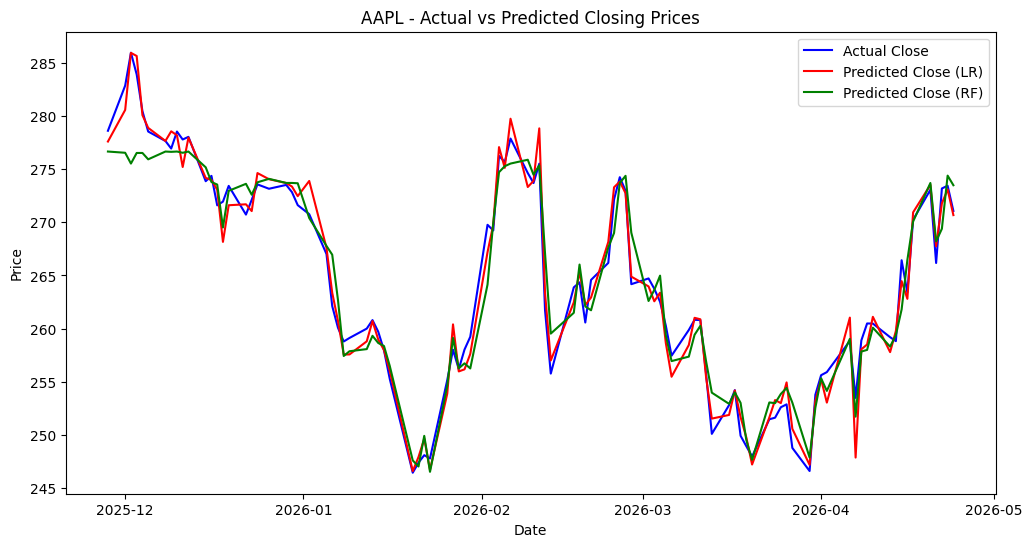

In [18]:
# Graph Size
plt.figure(figsize=(12,6))

# Actual Graph Line
plt.plot(y_test.index, y_test, label="Actual Close", color='blue')

# Graph line by LinearRegression
plt.plot(y_test.index, y_predict, label="Predicted Close (LR)", color='red')

# Graph line by RandomForest Regressor Model
plt.plot(y_test.index, y_pred, label="Predicted Close (RF)", color='green')

# Title of the Graph
plt.title(f"{ticker} - Actual vs Predicted Closing Prices")

# labels of the Axis
plt.xlabel("Date")
plt.ylabel("Price")

# Shows labels for each plotted line
plt.legend()

# Show the graph
plt.show()

Step 9: Feature Importance

In [19]:
# To identify the important Features
importances = rf_model.feature_importances_
for feat, imp in zip(features, importances):
    print(f"{feat}: {imp:.3f}")

Open: 0.014
High: 0.267
Low: 0.718
Volume: 0.001


**Model Comparison Analysis**

Key Observations

Linear Regression achieved significantly lower error (MSE) and higher R² score.
Random Forest underperformed despite being a more complex model.
Visual analysis supports these findings, with Linear Regression predictions closely aligning with actual values.

**Final Conclusion**

This study explored the use of machine learning models for short-term stock price prediction using historical market data.

The analysis revealed that:

Linear Regression outperformed Random Forest in both quantitative metrics and visual evaluation.
The strong predictive performance of Linear Regression indicates that the relationship between selected features and the closing price is predominantly linear.

Random Forest, while capable of modeling complex relationships, did not provide additional benefits in this case and may require further tuning.

**Key Takeaways**

Simpler models can outperform complex models when data relationships are linear.

Feature selection plays a critical role in model performance.
Visualization is essential for understanding model behavior beyond numerical metrics.

**Final Insight**

Effective machine learning is not about using the most advanced model, but about selecting the most appropriate model based on the nature of the data.

This project demonstrates the importance of combining statistical evaluation, visualization, and critical thinking to build reliable and interpretable predictive models.